In [3]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add parent directory to sys.path to import from src/
sys.path.append("..")
from src.utils import get_summary_stats

In [6]:
arr = np.array([1,2,3,4,5,6,7])
print("array: ", arr)
print("vectorized*2: ", arr*2)
print("vectorized squared: ", arr**2)

array:  [1 2 3 4 5 6 7]
vectorized*2:  [ 2  4  6  8 10 12 14]
vectorized squared:  [ 1  4  9 16 25 36 49]


In [7]:
large_list = list(range(100000))
large_arr = np.array(large_list)

print("\n--- Loop Speed ---")
%timeit [x * 2 for x in large_list]

print("\n--- Vectorized Speed ---")
%timeit large_arr * 2


--- Loop Speed ---
5.66 ms ± 423 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

--- Vectorized Speed ---
125 μs ± 29.8 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [19]:
data = Path("../data/raw/starter_data.csv")
df = pd.read_csv(data)
display(df.head())
print(df.info())

,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   category  10 non-null     str  
 1   value     10 non-null     int64
 2   date      10 non-null     str  
dtypes: int64(1), str(2)
memory usage: 372.0 bytes
None


In [21]:
display(df.describe())

summary_df = get_summary_stats(df, group_col='category', val_col='value')
display(summary_df)

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


,category,count,mean,std,min,max,sum
0,A,4,11.500000,1.290994,10,13,46
1,B,3,15.666667,2.081666,14,18,47
2,C,3,27.666667,2.516611,25,30,83


In [22]:
output_path = Path("../data/processed/summary.csv")
summary_df.to_csv(output_path, index=False)
print(f"Saved summary statistics to: {output_path}")

Saved summary statistics to: ../data/processed/summary.csv


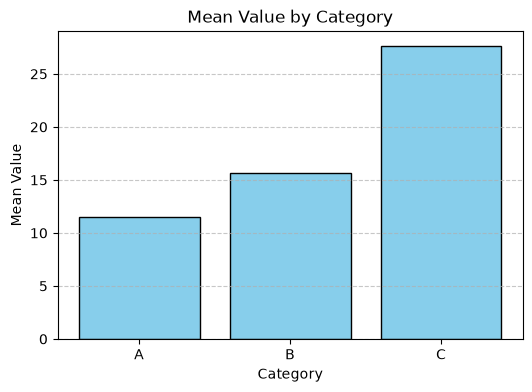

In [23]:
plt.figure(figsize=(6, 4))
plt.bar(summary_df['category'], summary_df['mean'], color='skyblue', edgecolor='black')
plt.title("Mean Value by Category")
plt.xlabel("Category")
plt.ylabel("Mean Value")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()